import imdlib as imd

**IMDLIB**

IMD Library
IMDLIB is a python package to download and handle binary gridded data from the India Meteorological Department (IMD). 
For more information about the IMD datasets, check the following link: IMD Pune.
https://imdlib.readthedocs.io/en/latest/Description.html



 Downloading from imd lib https://imdlib.readthedocs.io/en/latest/Description.html

In [108]:
#Install imdlib
!pip install imdlib
#import imdlib
import imdlib as imd
# xarry to read the data 
import xarray as xr
# for vector data handling 
import geopandas as gpd
# raster data handling 
import rioxarray
#For clipping data
from shapely.geometry import mapping
# foor plotting arrangements
import matplotlib.pyplot as plt
#numpy 
import numpy as np

# Acessing Rainfall data 

In [21]:
start_yr = 2000
end_yr = 2020
variable = 'rain' # other options are ('tmin'/ 'tmax')
data = imd.get_data(variable, start_yr, end_yr, fn_format='yearwise')

Downloading: rain for year 2000
Downloading: rain for year 2001
Downloading: rain for year 2002
Downloading: rain for year 2003
Downloading: rain for year 2004
Downloading: rain for year 2005
Downloading: rain for year 2006
Downloading: rain for year 2007
Downloading: rain for year 2008
Downloading: rain for year 2009
Downloading: rain for year 2010
Downloading: rain for year 2011
Downloading: rain for year 2012
Downloading: rain for year 2013
Downloading: rain for year 2014
Downloading: rain for year 2015
Downloading: rain for year 2016
Downloading: rain for year 2017
Downloading: rain for year 2018
Downloading: rain for year 2019
Downloading: rain for year 2020
Download Successful !!!


In [46]:
# convert to  xarray
rain=data.get_xarray()
rain

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 7671, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 61kB 2000-01-01 2000-01-02 ... 2020-12-31
Data variables:
    rain     (time, lat, lon) float64 1GB -999.0 -999.0 -999.0 ... -999.0 -999.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2026-07-14 15:40:02.456692 Python
    references:   
    comment:      
    crs:          epsg:4326

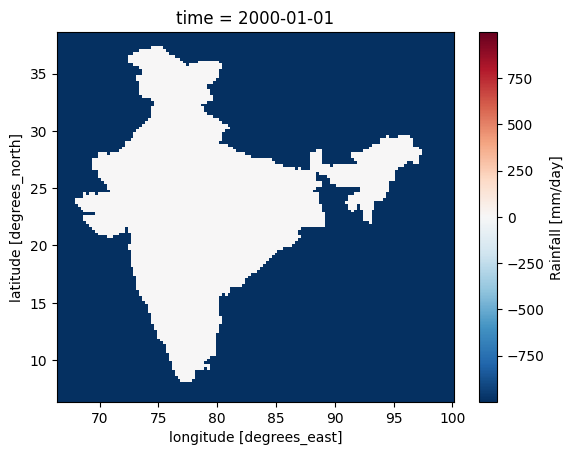

In [47]:
# visualizing 
rain['rain'][0].plot()

In [48]:
# priting Nodata values
print(rain['rain'][0].rio.nodata)

None


In [49]:
print(np.unique(rain['rain'][0].values,return_counts=True))

(array([-9.99000000e+02,  0.00000000e+00,  1.00805551e-01,  1.14980347e-01,
        1.23539887e-01,  1.28641665e-01,  1.37927756e-01,  1.63286030e-01,
        2.64677674e-01,  2.79641956e-01,  4.81867045e-01,  5.03803372e-01,
        9.41163778e-01,  1.58505893e+00,  1.98250043e+00,  2.23905754e+00,
        2.53671956e+00,  2.81390214e+00,  3.30849028e+00,  4.56570482e+00,
        1.16673002e+01,  1.17294159e+01,  1.48077135e+01]), array([12451,  4943,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1,     1,     1,     1,     1,
           1,     1,     1,     1,     1]))


The Nodata value is not saved as nodata in attributes, looking at the data the outlier is -999 so the nodata value since 12451 pixels are present and the ditribution of values shows .

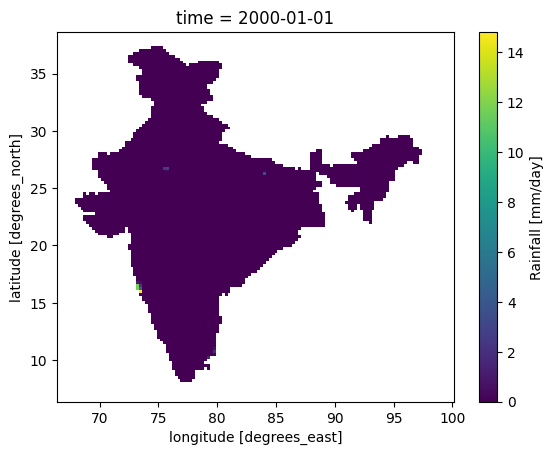

In [50]:
rain= rain.where(rain['rain'] != -999.)
rain['rain'][0].plot()

In [51]:
# Resolution of the data 
print('Resolution of data =',rain['rain'].rio.resolution())

Resolution of data = (0.25, 0.25)


In [52]:
rain['rain'].time

<xarray.DataArray 'time' (time: 7671)> Size: 61kB
array(['2000-01-01T00:00:00.000000000', '2000-01-02T00:00:00.000000000',
       '2000-01-03T00:00:00.000000000', ..., '2020-12-29T00:00:00.000000000',
       '2020-12-30T00:00:00.000000000', '2020-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 61kB 2000-01-01 2000-01-02 ... 2020-12-31
Attributes:
    standard_name:  time
    long_name:      time

In [55]:
rain['rain'].time[-1]

<xarray.DataArray 'time' ()> Size: 8B
array('2020-12-31T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2020-12-31
Attributes:
    standard_name:  time
    long_name:      time

In [69]:
print ("Start date =",rain['rain'].time[0].dt.strftime('%Y-%m-%d').item())
print ("End date =",rain['rain'].time[-1].dt.strftime('%Y-%m-%d').item())

start_year = int(rain['rain'].time[0].dt.strftime('%Y').item())
end_year = int(rain['rain'].time[-1].dt.strftime('%Y').item())
year_diff = end_year - start_year
print('Numbner of years=',year_diff)

Start date = 2000-01-01
End date = 2020-12-31
Numner of years= 20


# Loading Shapefile

       GID_1 GID_0 COUNTRY  NAME_1 VARNAME_1 NL_NAME_1 TYPE_1 ENGTYPE_1 CC_1  \
19  IND.17_1   IND   India  Kerala        NA        NA  State     State   NA   

   HASC_1  ISO_1                                           geometry  
19  IN.KL  IN-KL  MULTIPOLYGON (((77.25153 8.57099, 77.2597 8.54...  


Text(0.5, 1.0, 'Kerala')

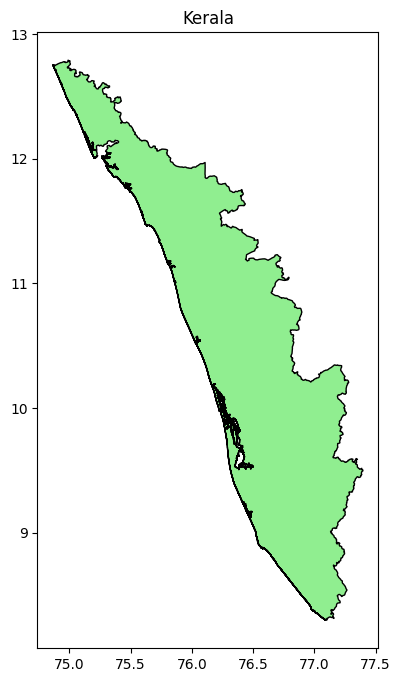

In [70]:
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_IND_shp.zip"

india = gpd.read_file(url, layer="gadm41_IND_1")

# Select Kerala
kerala = india[india["NAME_1"] == "Kerala"]

print(kerala)

# Plot
ax = kerala.plot(figsize=(6, 8), edgecolor='black', facecolor='lightgreen')
ax.set_title("Kerala")

# Clippping

In [74]:
print("Shapefile CRS:",kerala.crs)
print('Raster CRS:',rain['rain'].rio.crs)

Shapefile CRS: EPSG:4326
Raster CRS: None


In [79]:
# setting CRS 
rain['rain']=rain['rain'].rio.write_crs(kerala.crs)
# Clipping 
kerala_rain= rain['rain'].rio.clip(kerala.geometry.apply(mapping),
                                      kerala.crs,all_touched=True)# clipping data

Text(0.5, 1.0, 'Overlay')

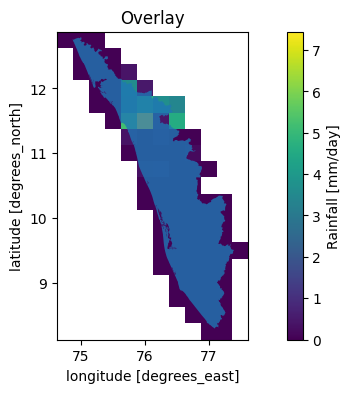

In [82]:
f, ax = plt.subplots(figsize=(10, 4))#plotting overlayed data

kerala_rain[122].plot()
kerala.plot(ax=ax,
                 alpha=.8)
plt.title("Overlay")

# Analysis 

In [84]:
#Spatial Average 
spat_avg=kerala_rain.mean(dim=["lat","lon"])

## Daily plot

Text(0.5, 1.0, 'Average daily Rainfall for Kerala: 2000-2020')

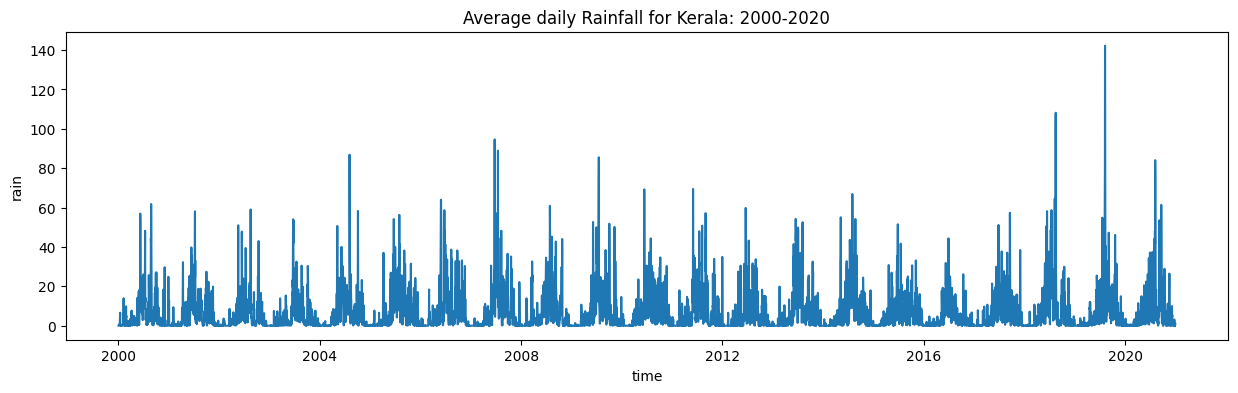

In [101]:
f, ax = plt.subplots(figsize=(15, 4))
spat_avg.plot()
plt.title(f"Average daily Rainfall for Kerala: {start_year}-{end_year}")

## Yearly plot

In [91]:
spat_avg

<xarray.DataArray 'rain' (time: 7671)> Size: 61kB
array([0.        , 0.        , 0.        , ..., 0.1291515 , 0.03841219,
       1.03075298])
Coordinates:
  * time         (time) datetime64[ns] 61kB 2000-01-01 2000-01-02 ... 2020-12-31
    spatial_ref  int64 8B 0

In [102]:
total_annual_rainfall=spat_avg.groupby('time.year').sum()
total_annual_rainfall

<xarray.DataArray 'rain' (year: 21)> Size: 168B
array([2163.09364077, 2151.1652006 , 1840.03289877, 1765.72858978,
       2331.56158378, 2378.40830952, 2814.03058653, 2801.57992545,
       2401.59268486, 2549.95828466, 2634.64347006, 2500.69007015,
       1873.99776445, 2654.11793371, 2531.90933668, 2232.30712126,
       1532.27962103, 2205.83392724, 3000.24091208, 2685.73121677,
       2572.18305974])
Coordinates:
    spatial_ref  int64 8B 0
  * year         (year) int64 168B 2000 2001 2002 2003 ... 2017 2018 2019 2020

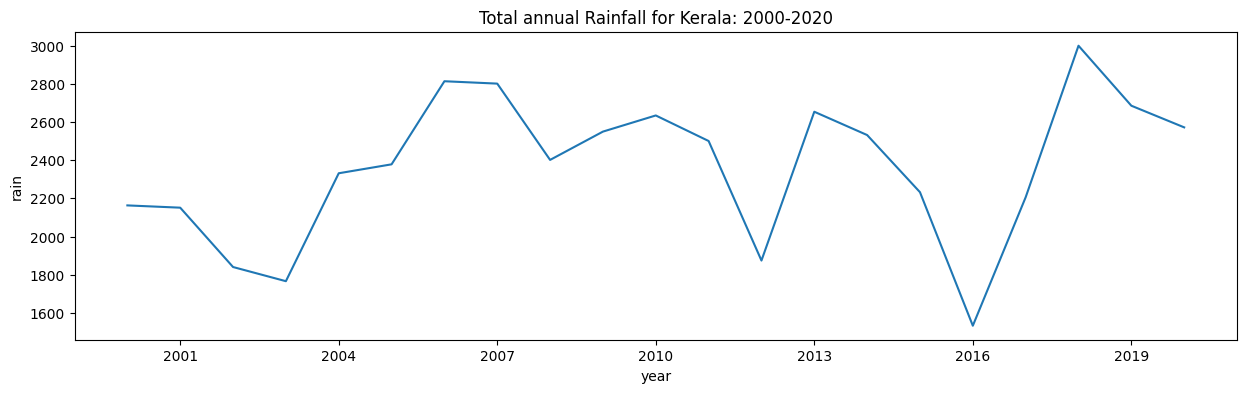

In [107]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(15, 4))

total_annual_rainfall.plot(ax=ax)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title(f"Total annual Rainfall for Kerala: {start_year}-{end_year}")
plt.show()
